In [2]:
# This script uses class definition to store, access and compute GP Observables in an organized manner

import GPKoopman as gpk
import torch
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import display, clear_output

print('Imported PyTorch version:', torch.__version__)
print('Imported NumPy version:', np.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

Imported PyTorch version: 2.5.1+cu124
Imported NumPy version: 2.2.1
True
NVIDIA GeForce RTX 3060 Laptop GPU


In [9]:
#A = 5 * torch.rand(3,3)

#x, xcv, y, ycv = gpk.sim_LTI(torch.ones(3), A=A, C=A, num_steps=20, x0cv=0.01*torch.eye(3))
#t = torch.linspace(0., 20., steps=20)
#xsd = xcv**0.5
#plt.plot(t, x[0,:])
#plt.fill_between(t, x[0,:] - 3*xsd[0,0,:], x[0,:] + 3*xsd[0,0,:], alpha=0.2)
#plt.grid()
#plt.show()


In [5]:
test = torch.cat([x.T, torch.zeros_like(x.T)])

In [13]:
def toeplitz_inverse(Toeplitz_matrix, tol=1e-6, max_iter=10):
    """
    Computes an approximate inverse of a Toeplitz matrix using 
    Preconditioned Conjugate Gradient (PCG) with FFT-based matrix-vector multiplication (MVM).
    
    Args:
        Toeplitz_matrix (torch.Tensor): Input square Toeplitz matrix (size n x n).
        tol (float): Convergence tolerance for PCG.
        max_iter (int): Maximum number of PCG iterations.
    
    Returns:
        torch.Tensor: Approximate inverse of the Toeplitz matrix.
    """
    # Ensure all computations are on the same device as the input matrix
    device = Toeplitz_matrix.device
    n = Toeplitz_matrix.size(0)
    
    # Extract first column (Toeplitz property: matrix is determined by its first column)
    first_col = Toeplitz_matrix[:, 0].to(device)

    # Define function for FFT-based Toeplitz matrix-vector multiplication
    def toeplitz_mvm(c, x):
        # Pad x to the size n+1 before applying FFT (to match fft_c)
        x_padded = torch.cat([x, torch.zeros_like(x).to(device)])  # x padded to length n+1
        
        # Create the circulant matrix by concatenating the first column and its flipped part
        circulant_column = torch.cat([c, torch.flip(c[1:], dims=(0,))]).to(device)
        
        # Apply FFT to both the circulant column and padded x
        fft_c = torch.fft.rfft(circulant_column)
        fft_x = torch.fft.rfft(x_padded)
        
        # Perform element-wise multiplication in the frequency domain
        fft_result = fft_c * fft_x[:n]
        
        # Inverse FFT to get the result back in the time domain
        result = torch.fft.irfft(fft_result, n=n)  # Only keep the first n elements
        return result

    # Initialize identity matrix and storage for inverse
    I = torch.eye(n, device=device)  # Identity matrix on the same device
    T_inv = torch.zeros_like(Toeplitz_matrix, device=device)  # Initialize inverse matrix

    # Solve for each column of the inverse matrix
    for i in range(n):
        b = I[:, i].to(device)  # Extract column of identity matrix
        x = torch.zeros_like(b).to(device)  # Initial guess (zero vector)
        r = b.clone()  # Initial residual
        z = r.clone()
        p = z.clone()
        rs_old = torch.dot(r, z)

        for _ in range(max_iter):
            Ap = toeplitz_mvm(first_col, p)  # Efficient matrix-vector multiplication using FFT
            alpha = rs_old / torch.dot(p, Ap)
            x += alpha * p
            r -= alpha * Ap

            if torch.norm(r) < tol:
                break  # Converged

            z = r.clone()  # Using identity preconditioner
            rs_new = torch.dot(r, z)
            beta = rs_new / rs_old
            p = z + beta * p
            rs_old = rs_new

        T_inv[:, i] = x  # Store computed column

    return T_inv

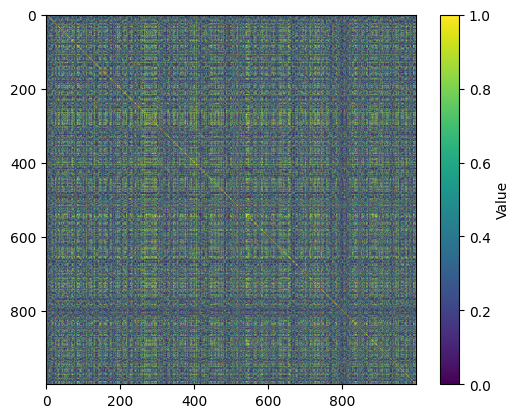

_LinAlgError: linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 7 is not positive-definite).

In [18]:
res = 1000
x = torch.linspace(0., 20., steps=res).view(1,res)
x2 = torch.vstack([x,x])
x3 = torch.rand(2,res)
y = gpk.KernelFunction(x3,x3,kernel_types=['Cosine'], hp1_list=[ torch.tensor(1.)], hp2_list=[ torch.tensor(1.)])


yplot = y.cpu().numpy()
#plt.plot(x,y.cpu())
plt.imshow(yplot)
plt.colorbar(label='Value')
plt.show()

L = torch.linalg.cholesky(y)
torch.min(y)
y_eig = torch.linalg.eigvals(y.cpu())

plt.plot(torch.real(y_eig), torch.imag(y_eig))
plt.grid()
plt.show()

#yinv = toeplitz_inverse(y)

### Cost Function Definition

In [3]:
# Multi-Trajectory Cost Function Definition

def get_cost_grid(Z, X, Xplus, Xtrain, manager, nT=1, lambda1=1.0, lambda2=1.0, lambda3=1.0):
    """
    Computes the cost function as defined in the Word doc, with different GP Kernel hyperparameters for
    each observable.

    Args:
        Z: Tensor of shape (r**n, p), decision variable, required grad
        X: Tensor of shape (n, nT*N), dataset of N steps from all trajectories
        Xall: Tensor of shape (n, nT*(N+1)), complete training dataset
        Xtrain: Tensor of shape (n, r**n), flattened set of gridpoints for training GPOs
        manager: Object of class GPObservablesManager (manager for all Gaussian Process based Observable functions)
        nT: float, number of trajectories in training dataset
        lambda1: float, Weighting for prediction error minimization term
        lambda2: float, Weightining for Reconstruction Error penalty term
    """
    
    N = (X.shape[1])//nT    # Number of time steps in each trajectory
    p = Z.shape[1]          # Number of Observables
    rpn = Z.shape[0]      # Decision Horizon
    n = X.shape[0]          # Dimensionality of original system

    for i in range(p):
        manager.train_observable(i, Xtrain, Z[:,i])

    # For current definition of GPOs
    # Training: Xtrain = dimensions x samples
    # Training: Ytrain = samples x (dimensions=1)
    # Prediction: Xquery = dimensions x num-query = Input
    # Prediction: Yquery = num-query x (dimensions=1) = Output

    # Lifting X and Xplus to higher dimension using trained GPOs
    M = torch.empty((p,N*nT))
    Mplus = torch.empty((p,N*nT))
    
    #Mall = torch.empty((p,(N+1)*nT))
    for i in range(p):
        M[i,:] = torch.transpose(manager.predict_mean(i, X), dim0=0, dim1=-1)
        Mplus[i,:] = torch.transpose(manager.predict_mean(i, Xplus), dim0=0, dim1=-1)
    
    # Compute C(z) and A(z)
    Mfull = torch.vstack((X, M))
    Mplusfull = torch.vstack((Xplus, Mplus))

    M_pinv = torch.linalg.pinv(Mfull)
    #Cz = X @ M_pinv
    Az = Mplusfull @ M_pinv
    C = torch.zeros((n,n+p))
    for i in range(n):
        C[i,i] = 1.
    
    # Cost term 1: Multi-Trajectory Prediction Error Minimization
    NormPEM = 0.0
    for j in range(nT):
        TrajPEM = 0.0
        for k in range(N - 1):
            #pred_error = Xplus[:, j*N + k] - C @ Az @ Mfull[:, j*N + k]    # one-step at X (with Cz)
            pred_error = X[:, j*N + (k+1)] - C @ (torch.linalg.matrix_power(Az,k+1)) @ Mfull[:,j*N]   # multi-step at X (with Cz)
            TrajPEM += torch.norm(pred_error)
        NormPEM += TrajPEM

    
    # Weighted sum of terms
    cost = (lambda1 * NormPEM/(N*nT))
    return cost



# Execution Cells

## Data Generation

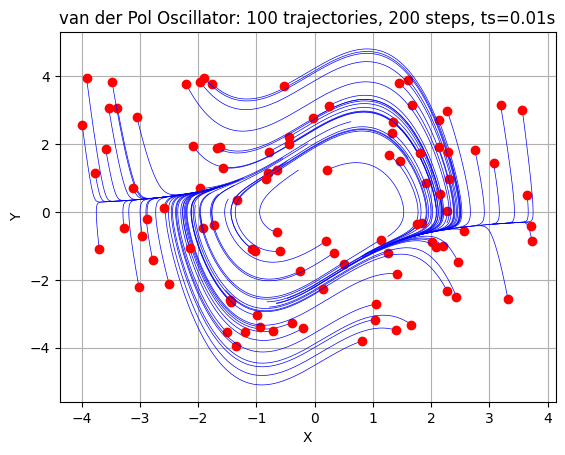

In [4]:
# Multi-Trajectory Data Generation
nT = 100    # number of trajectories
N = 200     # number of time-steps per trajectory
ts = 0.01   # sampling time

torch.manual_seed(1234)   # reproducible random number
randIC = -torch.tensor([4., 4.]).view(2,1) + torch.tensor([8., 8.]).view(2,1) * torch.rand(2,nT)
SimData = torch.empty(2,nT*(N+1))

for j in range(nT):
    SimData[:, (j*(N+1)):(j+1)*(N+1)] = gpk.sim_RK4(gpk.f_VDP, randIC[:,j], ts=ts, num_steps=N+1, params=[1.])

# Visualization
plt.figure()
for j in range(nT):
    plt.plot(SimData[0, (j*(N+1)):(j+1)*(N+1)], SimData[1, (j*(N+1)):(j+1)*(N+1)], color='blue', linewidth=0.5)
    plt.plot(SimData[0,j*(N+1)], SimData[1, j*(N+1)], 'o', color='red')

#plt.title(f"Duffing Oscillator: {nT} Trajectories of {N+1} steps each")
#plt.title(f"Simple Damped Pendulum: {nT} trajectories, {N} steps, ts={ts}s")
plt.title(f"van der Pol Oscillator: {nT} trajectories, {N} steps, ts={ts}s")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()


## Optimization Section

### Find Optimal Z Values

In [ ]:
# Original and Koopman Model parameters
# n = 2   # original states
# N = 50  # data-points
Xall = SimData.float()
n = Xall.shape[0]
p = 20  # number of lifted states
#l = 75  # decision horizon for each lifted state
r = 10   # resolution along all dimensions

X = torch.cat([Xall[:,j*(N+1):j*(N+1)+N] for j in range(nT)],dim=1)         # Data matrix from original system
Xplus = torch.cat([Xall[:,j*(N+1)+1:j*(N+1)+N+1] for j in range(nT)],dim=1) # Time-shifted data matrix

# GPO Training Grid
gridpoints0 = torch.linspace(0., 0.1, steps=r)
gridpoints1 = torch.linspace(0., 0.1, steps=r)
grid0, grid1 = torch.meshgrid(gridpoints0, gridpoints1, indexing='xy')
Xtrain = torch.stack([torch.flatten(grid0), torch.flatten(grid1)])

# Initialize Decision Variables
Z = torch.rand(r**n, p, requires_grad=True)   # Shape: (r**n)-by-p

ObsManager = gpk.GPObservablesManager()
for i in range(p):
    ObsManager.add_observable(index=i, d=n, ns=r**n, kernel_types=['Gaussian','Cosine'],combination='sum')

ObsManager.set_random_hyperparameters(scale=1.0)
print('Observable Hyperparameters have been randomized')

cost = get_cost_grid(Z, X, Xplus, Xtrain, ObsManager, nT=nT, lambda1=1.)


Observable Hyperparameters have been randomized


In [6]:
print(f'Total Observables available: {gpk.GPObservable.count_Observables()}')

# Optimization Parameters
max_iter = 200
learn_rate = 0.02   # Learning Rate    
err_thresh = 0.01    # Target Cost
patience = 40       # Number of iterations to monitor for significant change
min_delta = 5e-3    # Minimum required decrease in cost for significance

optimizer = torch.optim.Adam([Z, ObsManager.get_all_params()], lr=learn_rate)    # Optimizer  

print('Starting Iteration Loop!')
cost_history = []
iter = 0
count_insignificant = 0

while iter < max_iter:
    optimizer.zero_grad()  # Clear gradients

    # Compute cost
    cost = get_cost_grid(Z, X, Xplus, Xtrain, ObsManager, nT=nT, lambda1=10.)
    
    cost_history.append(cost.item())

    # Backpropagation
    cost.backward()

    # Optimization step
    optimizer.step()

    print(f"Iteration {iter + 1}/{max_iter} with {count_insignificant} Insignificant Iterations")
    print(f"Cost: {cost.item()}")

    # Stopping conditions
    if cost.item() < err_thresh:
        print("Stopping: Error threshold reached.")
        break

    # Check for significant improvement
    if iter > patience:
        error_change = cost_history[-patience] - cost_history[-1]
        if error_change < min_delta or error_change < 0:
            count_insignificant += 1
        else:
            count_insignificant = 0

        if count_insignificant >= patience:
            print("Stopping: No significant improvement over consecutive iterations.")
            break

    # Increment iteration
    iter += 1


if iter == max_iter:
    print(f'Stopping: Reached maximum number of iterations = {iter}.')


optimal_Z = Z.detach()

print('Optimization Complete.')
print("Final Cost:", cost.item())

#plt.ioff()
#plt.show()

# Plot cost history
plt.figure(figsize=(8, 6))
plt.plot(cost_history, label="Cost")
plt.title("Cost History")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.legend()
plt.grid()
plt.show()


Total Observables available: 25
Starting Iteration Loop!
Iteration 1/200 with 0 Insignificant Iterations
Cost: 10.852622985839844
Iteration 2/200 with 0 Insignificant Iterations
Cost: 10.965737342834473
Iteration 3/200 with 0 Insignificant Iterations
Cost: 10.822754859924316
Iteration 4/200 with 0 Insignificant Iterations
Cost: 10.822319030761719
Iteration 5/200 with 0 Insignificant Iterations
Cost: 15.200092315673828
Iteration 6/200 with 0 Insignificant Iterations
Cost: 14.935869216918945
Iteration 7/200 with 0 Insignificant Iterations
Cost: 14.78719711303711
Iteration 8/200 with 0 Insignificant Iterations
Cost: 14.704397201538086
Iteration 9/200 with 0 Insignificant Iterations
Cost: 22.924680709838867
Iteration 10/200 with 0 Insignificant Iterations
Cost: 22.919815063476562
Iteration 11/200 with 0 Insignificant Iterations
Cost: 22.920143127441406
Iteration 12/200 with 0 Insignificant Iterations
Cost: 22.91996955871582
Iteration 13/200 with 0 Insignificant Iterations
Cost: 22.91842842

KeyboardInterrupt: 

### Post-Process Optimization Results

In [6]:
# Use Optimal Z values to Build GP Models and Optimal A and Z matrices
optimal_Z = Z.detach()
for i in range(p):
    ObsManager.train_observable(i, Xtrain, optimal_Z[:,i])  # train GP Observables with Optimal Z outputs

ObsManager.optim_GP_hyperparams()   # Optimize Kernel hyperparameters for Optimal training data

# Plot Optimal GP Response Shape within Domain
#ObsManager.plot_observables(range_x=(-3,3), range_y=(-3,3))

ObsList = [i for i in range(p)]

A, C = gpk.getKoopman(ObsManager, ObsList, Xall, nT, stateAug=True)


## Simulation and Validation

In [ ]:
#initial_state = torch.tensor([244.4171, 271.7376], dtype=torch.float64)
val_steps = 200

Xq = torch.empty((2,1))
Xq[:,0] = torch.tensor([-1.099, -0.996])    # IC for Duffing Oscillator
Xq[:,0] = randIC[:,20]
Xq[:,0] = torch.tensor([2., -2.])

#Xq[:,0] = torch.tensor([0.95*244.4171, 0.95*271.7376])    # IC for Lotka-Volterra
# Validation IC for Duffing Oscillator from Clemson paper = -1.0993779695641197, -0.9956159478504363

# Simulate the system
#ValData = simulate_system(torch.tensor([-1.099, -0.996]), val_steps, DuffingOscillator)
# data for van der Pol Oscillator is 1., 0.2
ValData = gpk.sim_RK4(gpk.f_VDP, Xq[:,0], ts=ts, num_steps=val_steps, params=[1.])

Zmean = torch.empty((p,1))
Zcv = torch.empty((p,1))

for i in range(p):
    Zmean[i,0] = ObsManager.predict_mean(i, Xq)
    Zcv[i,0] = ObsManager.predict_covariance(i, Xq)

Z0 = torch.vstack((Xq, Zmean))
Z0cv = torch.vstack(([[1.], [1.]], Zcv))
Z0cv = torch.diag(Z0cv)
#TrajZ, Xhat = gpk.linear_simulation(Z0, A, C, num_steps=val_steps)

TrajZ, TrajZcv, Xhat, Xcvhat = gpk.sim_LTI(Z0, A, C, num_steps=val_steps, ts=0.01, x0cv=Z0cv)

Xhat = Xhat.detach()

# Eigen value plot of Koopman Matrices
eigval = torch.linalg.eigvals(A)

eigreal = eigval.real
eigimag = eigval.imag

eigreal = eigreal.detach().numpy()
eigimag = eigimag.detach().numpy()

theta = np.linspace(0, 2*np.pi, 500)
unitCirclex = np.cos(theta)
unitCircley = np.sin(theta)

plt.figure(2,figsize=(10, 6))
plt.plot(Xhat[0,:], Xhat[1,:], label='GPO-Koopman')
plt.plot(ValData[0,:val_steps], ValData[1, :val_steps], label='Nonlinear', linestyle='--')
plt.plot(Xq[0,0], Xq[1,0], label='IC', marker='o')
plt.title(f"Validation of Optimal GPO-K model for van der Pol Oscillator")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid()
plt.show()

PredRMSE = torch.sqrt(torch.mean((Xhat - ValData[:,:val_steps])**2,1))

print(f'RMS Error for X is: {PredRMSE[0]}')
print(f'RMS Error for Y is: {PredRMSE[1]}')

plt.figure(3, figsize=(10,6))
plt.plot(Xhat[0,:], label='X - GPO-K')
plt.plot(Xhat[1,:], label='Y - GPO-K')
plt.plot(ValData[0,:val_steps], label='X - NL', linestyle='--')
plt.plot(ValData[1,:val_steps], label='Y - NL', linestyle='--')
plt.xlabel('Time-step')
plt.ylabel('Position')
plt.title(f'Evolution of System States for {val_steps} steps')
plt.legend()
plt.grid()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# First subplot: Eigenvalues plot
axes[0].plot(unitCirclex, unitCircley, color='red', label='Unit Circle')
axes[0].scatter(eigreal, eigimag, color='blue', label='Eigenvalues')
axes[0].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.5, linestyle='--')
axes[0].set_title(f"Eigenvalues of A Matrix with {p} Observables")
axes[0].set_xlabel("Real Part")
axes[0].set_ylabel("Imaginary Part")
axes[0].grid(True)
axes[0].legend(loc='upper right')

# Second subplot: Heatmap of matrix A
im = axes[1].imshow(A.detach().numpy(), cmap='viridis', aspect='auto')
fig.colorbar(im, ax=axes[1], label="Value")
axes[1].set_title(f'{A.shape[0]}-D Koopman Matrix')
axes[1].set_xlabel("Columns")
axes[1].set_ylabel("Rows")

# Adjust layout for better spacing
plt.tight_layout()

# Show the figure
plt.show()

## Phase Plot of Koopman Linear Model
TrainRMSE = torch.zeros((n,nT))
fig, ax = plt.subplots(figsize=(8, 6))
for j in range(nT):  # Loop over different initial conditions
    x0 = randIC[:, j].view(n,1)  # Select one initial condition
    Z0ph = torch.zeros((p,1))
    for i in range(p):
        Z0ph[i,0] = ObsManager.predict_mean(i, x0)
    Z0ph = torch.vstack((x0, Z0ph))
    phstates, phoutputs = gpk.linear_simulation(Z0ph, A, C, num_steps=N, ts=ts)  # Simulate system
    TrainRMSE[:,j] = torch.sqrt(torch.mean((X[:, j*N : (j+1)*N] - phoutputs)**2,1))
    # Plot phase trajectory (assuming a 2D phase space: first two states)
    ax.plot(phoutputs.detach().numpy()[0, :], phoutputs.detach().numpy()[1, :], alpha=0.6, color='blue')

# Configure plot
ax.set_title("Phase Plot of Koopman Linear System")
ax.set_xlabel("X1: Theta")
ax.set_ylabel("X2: Omega")
ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax.grid(True)

plt.show()




In [ ]:
plt.plot(TrainRMSE.detach().numpy()[0,:], color='blue', label='X1', alpha=0.5)
plt.plot(TrainRMSE.detach().numpy()[1,:], color='red', label='X2', alpha=0.5)
plt.xlabel('Trajectory')
plt.ylabel('RMSE')
plt.title(f'Koopman Linear Model RMSE for {nT} Training Trajectories')
plt.legend()
plt.grid()
plt.show()